# Predicting Chess Puzzle Difficulty
**Regression Models:** Linear Regression, Smoothing Splines, Neural Networks

### Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [2]:
# load in data
fragment_1 = pd.read_csv("data/depth_union.csv")
fragment_2 = pd.read_csv("data/lichess_db_puzzle_first_100000.csv")
fragment_3 = pd.read_csv("data/move_table_output_100000.csv")

# combine data
df = pd.merge(pd.merge(fragment_1, fragment_2, on="PuzzleId"), fragment_3, on="PuzzleId")

df

,PuzzleId,type,value,success,depth,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,MovesAmt,Possible_Moves
0,00008,cp,231,True,1,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,2107,78,95,9243,crushing hangingPiece long middlegame,https://lichess.org/787zsVup/black#48,NaN,6,35
1,0000D,cp,-11,True,1,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1535,73,95,35791,advantage endgame short,https://lichess.org/F8M8OS71#53,NaN,4,40
2,0008Q,cp,705,True,1,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1385,80,92,762,advantage endgame rookEndgame short,https://lichess.org/MQSyb3KW#127,NaN,4,16
3,0009B,cp,111,True,1,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1084,74,88,605,advantage middlegame short,https://lichess.org/4MWQCxQ6/black#32,Kings_Pawn_Game Kings_Pawn_Game_Leonardis_Vari...,4,39
4,000Pw,cp,279,True,1,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1542,75,92,622,crushing endgame fork short,https://lichess.org/au2lCK5o#73,NaN,4,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,140tv,cp,14,True,9,3r2k1/p3pp2/Pqp3pp/1p2P1N1/1Qb2P2/5BP1/7P/2R4K...,g5e4 b6e3 b4e1 e3f3,1706,75,99,2652,crushing fork middlegame short,https://lichess.org/RzL8Wnxz#59,NaN,4,42
1199996,140wi,cp,9,True,9,r3r1k1/pp1qppbp/3p2p1/2pNn1B1/2P1P3/3P3P/PP1Q1...,e7e6 d5f6 g7f6 g5f6,1146,75,89,206,crushing fork middlegame short,https://lichess.org/RQ4wLQyf/black#28,Sicilian_Defense Sicilian_Defense_Canal_Attack,4,37
1199997,140wu,cp,453,True,9,4nB2/pp5k/2p1P1rp/5Q2/3P4/1P6/P4RBK/4q3 w - - ...,g2e4 e1g1 h2h3 g1g3,1136,86,68,32,mate mateIn2 middlegame short,https://lichess.org/hnlY3PnR#79,NaN,4,45
1199998,140zC,cp,277,True,9,8/p4R1k/1p2N2p/3b2p1/2p1n1B1/P1P3P1/1r5P/6K1 b...,h7h8 f7f8 h8h7 g4f5,970,76,91,292,endgame mate mateIn2 short,https://lichess.org/QXoGIJd8/black#72,NaN,4,3


## Clean + Normalize Data

In [3]:
# remove incomplete entried
df = df.dropna(subset=['PuzzleId', 'type', 'value', 'success', 'depth', 'Rating', 'MovesAmt', 'Possible_Moves'])
df

,PuzzleId,type,value,success,depth,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,MovesAmt,Possible_Moves
0,00008,cp,231,True,1,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,2107,78,95,9243,crushing hangingPiece long middlegame,https://lichess.org/787zsVup/black#48,NaN,6,35
1,0000D,cp,-11,True,1,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1535,73,95,35791,advantage endgame short,https://lichess.org/F8M8OS71#53,NaN,4,40
2,0008Q,cp,705,True,1,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1385,80,92,762,advantage endgame rookEndgame short,https://lichess.org/MQSyb3KW#127,NaN,4,16
3,0009B,cp,111,True,1,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1084,74,88,605,advantage middlegame short,https://lichess.org/4MWQCxQ6/black#32,Kings_Pawn_Game Kings_Pawn_Game_Leonardis_Vari...,4,39
4,000Pw,cp,279,True,1,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1542,75,92,622,crushing endgame fork short,https://lichess.org/au2lCK5o#73,NaN,4,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199995,140tv,cp,14,True,9,3r2k1/p3pp2/Pqp3pp/1p2P1N1/1Qb2P2/5BP1/7P/2R4K...,g5e4 b6e3 b4e1 e3f3,1706,75,99,2652,crushing fork middlegame short,https://lichess.org/RzL8Wnxz#59,NaN,4,42
1199996,140wi,cp,9,True,9,r3r1k1/pp1qppbp/3p2p1/2pNn1B1/2P1P3/3P3P/PP1Q1...,e7e6 d5f6 g7f6 g5f6,1146,75,89,206,crushing fork middlegame short,https://lichess.org/RQ4wLQyf/black#28,Sicilian_Defense Sicilian_Defense_Canal_Attack,4,37
1199997,140wu,cp,453,True,9,4nB2/pp5k/2p1P1rp/5Q2/3P4/1P6/P4RBK/4q3 w - - ...,g2e4 e1g1 h2h3 g1g3,1136,86,68,32,mate mateIn2 middlegame short,https://lichess.org/hnlY3PnR#79,NaN,4,45
1199998,140zC,cp,277,True,9,8/p4R1k/1p2N2p/3b2p1/2p1n1B1/P1P3P1/1r5P/6K1 b...,h7h8 f7f8 h8h7 g4f5,970,76,91,292,endgame mate mateIn2 short,https://lichess.org/QXoGIJd8/black#72,NaN,4,3


In [4]:
const_cols = ['Rating', 'MovesAmt', 'Possible_Moves']
depth_cols = ['type', 'value', 'success']

# split
df_meta = df.groupby("PuzzleId")[const_cols].first().reset_index()
df_depth = df[["PuzzleId", "depth"] + depth_cols]

# unstack depth-dependent entries
df_pivot = df_depth.pivot(index='PuzzleId', columns='depth', values=depth_cols)
df_pivot.columns = [f'depth_{depth}_{col}' for col, depth in df_pivot.columns]
df_pivot = df_pivot.reindex(sorted(df_pivot.columns, key=lambda c: int(c.split('_')[1])), axis=1)
df_pivot = df_pivot.reset_index()

# rejoin
df_result = df_meta.merge(df_pivot, on='PuzzleId')

# encode type columns
type_cols = [c for c in df_result.columns if c.endswith('_type')]
df_result[type_cols] = df_result[type_cols].replace({'cp': 0, 'mate': 1})

In [5]:
# reasonable values for value
df_value_mate = df_result.copy()
for i in range(1, 13):
    col = f'depth_{i}_value'
    type_col = f'depth_{i}_type'
    mask = df_value_mate[type_col] == 'mate'
    df_value_mate.loc[mask, col] = np.sign(df_value_mate.loc[mask, col]) * 1000

In [6]:
# normalize data
scaler = StandardScaler()
cols_to_scale = ['MovesAmt', 'Possible_Moves', 'depth_1_value', 'depth_2_value', 'depth_3_value', 'depth_4_value', 'depth_5_value', 'depth_6_value', 'depth_7_value', 'depth_8_value', 'depth_9_value', 'depth_10_value', 'depth_11_value', 'depth_12_value']
df_value_mate[cols_to_scale] = scaler.fit_transform(df_value_mate[cols_to_scale])
df_value_mate


,PuzzleId,Rating,MovesAmt,Possible_Moves,depth_1_type,depth_1_value,depth_1_success,depth_2_type,depth_2_value,depth_2_success,...,depth_9_success,depth_10_type,depth_10_value,depth_10_success,depth_11_type,depth_11_value,depth_11_success,depth_12_type,depth_12_value,depth_12_success
0,00008,2107,0.739318,0.505402,0,0.698371,True,0,0.674294,True,...,True,0,0.366062,True,0,0.542591,True,0,0.608142,True
1,0000D,1535,-0.341572,0.853945,0,-0.636613,True,0,-0.536068,True,...,True,0,-0.441502,True,0,-0.440970,True,0,-0.455077,True
2,0008Q,1385,-0.341572,-0.819060,0,3.313176,True,0,0.196383,True,...,True,0,0.603845,True,0,1.415391,True,0,1.213828,True
3,0009B,1084,-0.341572,0.784236,0,0.036396,True,0,0.300276,True,...,True,0,0.814709,True,0,0.591326,True,0,0.664789,True
4,000Pw,1542,-0.341572,0.435694,0,0.963162,True,0,1.359992,True,...,True,0,1.092870,True,0,1.056524,True,0,0.860874,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,140tv,1706,-0.341572,0.993362,0,-0.129098,True,0,-0.063352,True,...,True,0,-0.647879,True,0,-0.166282,True,0,-0.306924,True
99996,140wi,1146,-0.341572,0.644819,0,-0.592481,True,0,-0.411396,True,...,True,0,-0.401123,True,0,-0.347930,True,0,-0.455077,True
99997,140wu,1136,-0.341572,1.202488,0,1.630654,True,0,1.848293,True,...,True,0,1.447301,True,0,1.592609,True,0,1.640859,True
99998,140zC,970,-0.341572,-1.725271,0,-0.118065,True,0,0.201577,True,...,True,0,1.173626,True,0,1.043232,True,0,1.314050,True


In [7]:
success_cols = [f'depth_{d}_success' for d in range(1, 13)]
data = df_value_mate.copy()
data[success_cols] = df_value_mate[success_cols].astype(int)
data

,PuzzleId,Rating,MovesAmt,Possible_Moves,depth_1_type,depth_1_value,depth_1_success,depth_2_type,depth_2_value,depth_2_success,...,depth_9_success,depth_10_type,depth_10_value,depth_10_success,depth_11_type,depth_11_value,depth_11_success,depth_12_type,depth_12_value,depth_12_success
0,00008,2107,0.739318,0.505402,0,0.698371,1,0,0.674294,1,...,1,0,0.366062,1,0,0.542591,1,0,0.608142,1
1,0000D,1535,-0.341572,0.853945,0,-0.636613,1,0,-0.536068,1,...,1,0,-0.441502,1,0,-0.440970,1,0,-0.455077,1
2,0008Q,1385,-0.341572,-0.819060,0,3.313176,1,0,0.196383,1,...,1,0,0.603845,1,0,1.415391,1,0,1.213828,1
3,0009B,1084,-0.341572,0.784236,0,0.036396,1,0,0.300276,1,...,1,0,0.814709,1,0,0.591326,1,0,0.664789,1
4,000Pw,1542,-0.341572,0.435694,0,0.963162,1,0,1.359992,1,...,1,0,1.092870,1,0,1.056524,1,0,0.860874,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,140tv,1706,-0.341572,0.993362,0,-0.129098,1,0,-0.063352,1,...,1,0,-0.647879,1,0,-0.166282,1,0,-0.306924,1
99996,140wi,1146,-0.341572,0.644819,0,-0.592481,1,0,-0.411396,1,...,1,0,-0.401123,1,0,-0.347930,1,0,-0.455077,1
99997,140wu,1136,-0.341572,1.202488,0,1.630654,1,0,1.848293,1,...,1,0,1.447301,1,0,1.592609,1,0,1.640859,1
99998,140zC,970,-0.341572,-1.725271,0,-0.118065,1,0,0.201577,1,...,1,0,1.173626,1,0,1.043232,1,0,1.314050,1


## Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [9]:
feature_cols = [c for c in data.columns if c not in ["PuzzleId", "Rating"]]
X = data[feature_cols] # inputs
y = data['Rating']     # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# train model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# test model
y_pred = model.predict(X_test)

# results
print(f'MAE: {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R^2: {r2_score(y_test, y_pred):.4f}')

MAE: 332.8346
R^2: 0.4367


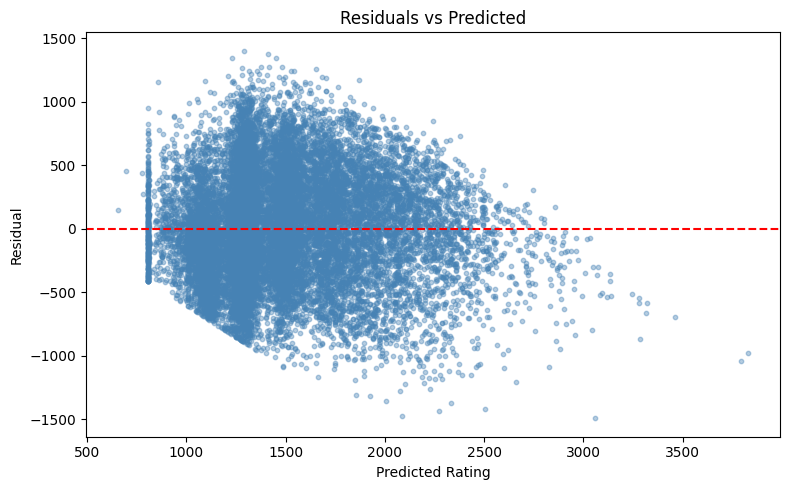

In [12]:
# plot residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, s=10, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Rating')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

## Neural Network

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [14]:
# prep data
feature_cols = [c for c in data.columns if c not in ['PuzzleId', 'Rating']]
X = data[feature_cols].fillna(0).values.astype(np.float32)
y = data['Rating'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# convert to tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train).unsqueeze(1)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

In [15]:
# define model
class RatingNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = RatingNet(X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [16]:
# train
epochs = 100
for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_test_t), y_test_t).item()
        print(f"Epoch {epoch+1:3d} — val MSE: {val_loss:.1f}  val MAE: {np.mean(np.abs(model(X_test_t).detach().numpy() - y_test_t.detach().numpy())):.1f}")

Epoch  10 — val MSE: 171757.2  val MAE: 333.7
Epoch  20 — val MSE: 165283.9  val MAE: 329.6
Epoch  30 — val MSE: 165909.6  val MAE: 329.7
Epoch  40 — val MSE: 164566.3  val MAE: 328.8
Epoch  50 — val MSE: 166798.5  val MAE: 329.6
Epoch  60 — val MSE: 164075.0  val MAE: 328.3
Epoch  70 — val MSE: 166274.7  val MAE: 329.6
Epoch  80 — val MSE: 165620.2  val MAE: 329.0
Epoch  90 — val MSE: 162699.6  val MAE: 326.2
Epoch 100 — val MSE: 164660.4  val MAE: 327.5


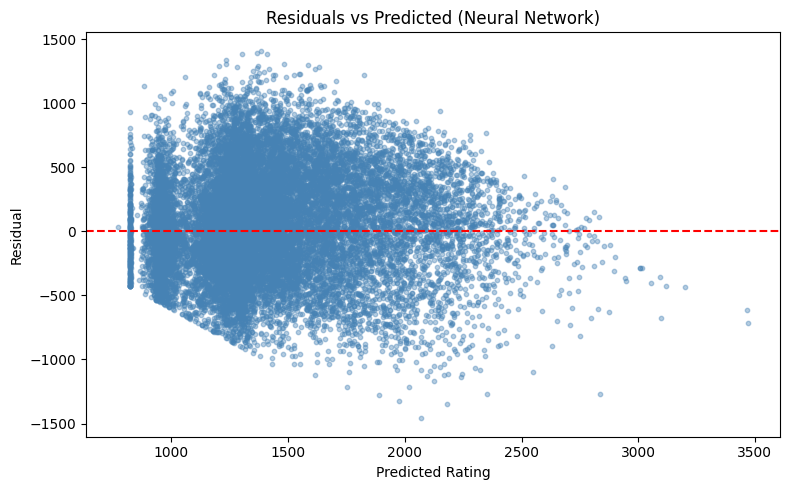

In [17]:
# final eval
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).numpy().flatten()

residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, s=10, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Rating')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (Neural Network)')
plt.tight_layout()
plt.show()

## Lasso Regression

In [18]:
from sklearn.linear_model import Lasso

In [19]:
# create + train model
model = Lasso(alpha=0.1)
model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [20]:
# eval
y_pred = model.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R^2: {r2_score(y_test, y_pred):.4f}')

MAE: 332.8228
R^2: 0.4368


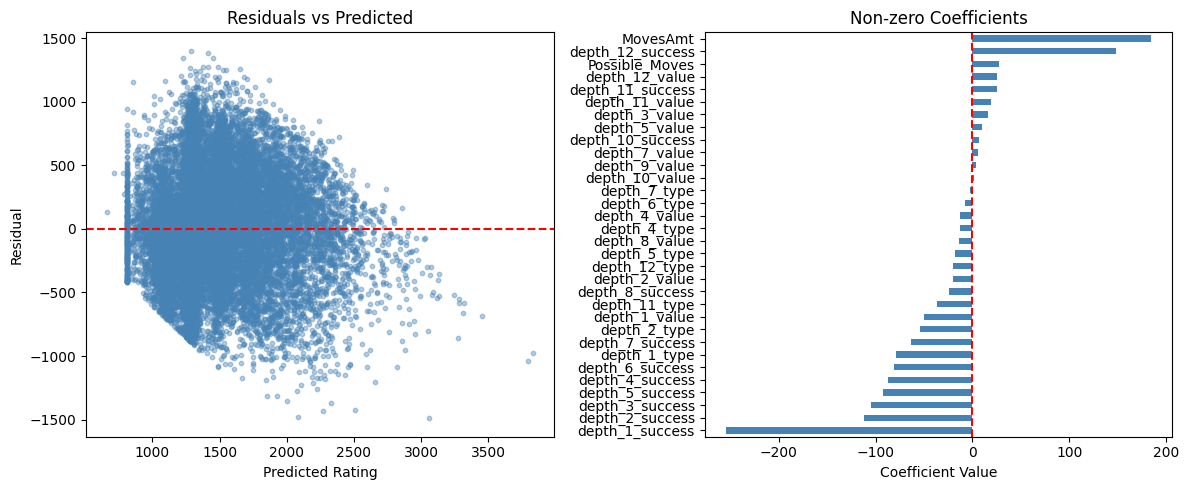

In [21]:
# visualize
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# residual plot
axes[0].scatter(y_pred, residuals, alpha=0.4, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Rating')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# non-zero coefficients
coefs = pd.Series(model.coef_, index=feature_cols)
nonzero = coefs[coefs != 0].sort_values()
nonzero.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Non-zero Coefficients')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()